<a href="https://colab.research.google.com/github/sevilresearch/ARGO-CAT/blob/main/ARGO_CAT_Backend_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARGO-CAT Phase 2 — Backend Pipeline

---

## Pipeline Overview

This notebook implements Phase 2 of the ARGO-CAT behavioral digital twin. The system passively monitors eating and drinking behavior in older adults with Mild Cognitive Impairment using computer vision and behavioral anomaly detection.

The pipeline is organized into three stages:

| Stage | Purpose |
|---|---|
| **Stage 1 — CV Model** | Load the object detection model and confirm it detects food and drink objects |
| **Stage 2A — Event Logging** | Define the database schema and logging functions that write every detection to persistent storage |
| **Stage 2B — Synthetic Data** | Populate the database with 30 days of simulated behavioral history to provide a baseline for the anomaly checker |
| **Stage 3 — Anomaly Detection** | Read the event history, compute personalized risk scores, and produce action recommendations |

---

> **Before running:** Go to `Runtime > Change runtime type > T4 GPU > Save`
>
> **Run order:** Execute each cell top to bottom, one at a time.
---

In [ ]:
import torch

if torch.cuda.is_available():
    print(f"✅  GPU : {torch.cuda.get_device_name(0)}")
else:
    print("❌  No GPU detected.")

✅  GPU : Tesla T4


### Install and import packages

Installs and imports all libraries needed across the notebook.

- `ultralytics` — YOLO object detection framework
- `opencv-python-headless` — image reading and processing
- `scikit-learn` — Isolation Forest for anomaly detection (used in later phases)
- `scipy` — linear regression for longitudinal trend analysis

> Takes approximately 60 seconds. A large amount of output is normal. Wait for the final confirmation line before continuing.

In [ ]:
get_ipython().system(
    'pip install ultralytics opencv-python-headless '
    'scikit-learn scipy -q'
)

import cv2
import numpy as np
import pandas as pd
import sqlite3
import csv
import os
import io
import random
import time
from datetime import datetime, timedelta
from PIL import Image
from IPython.display import display, Image as IPImage
from sklearn.ensemble import IsolationForest

random.seed(42)
np.random.seed(42)

print("✅  All packages installed and imported")



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.5 MB/s eta 0:00:00
✅  All packages installed and imported


### Mount Google Drive

Connects Google Drive to this Colab session so all files survive when the session ends.

All outputs are saved to `My Drive/ARGO_CAT/` with the following structure:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ROOT    = '/content/drive/MyDrive/UWF RRC 2026/ARGO_CAT'
MODELS  = f'{ROOT}/models'
LOGS    = f'{ROOT}/logs'

for folder in [ROOT, MODELS, LOGS]:
    os.makedirs(folder, exist_ok=True)

DB_PATH  = f'{LOGS}/argo_cat.db'
CSV_PATH = f'{LOGS}/detections.csv'

print("✅  Google Drive mounted")
print(f"    Root    : {ROOT}")
print(f"    Database: {DB_PATH}")
print(f"    CSV log : {CSV_PATH}")

Mounted at /content/drive
✅  Google Drive mounted
    Root    : /content/drive/MyDrive/ARGO_CAT
    Database: /content/drive/MyDrive/ARGO_CAT/logs/argo_cat.db
    CSV log : /content/drive/MyDrive/ARGO_CAT/logs/detections.csv


---

## Stage 1 — Computer Vision Model

The CV model is the first layer of the ARGO-CAT pipeline. It processes images from the camera and identifies food and drink objects. All downstream stages depend on the output of this stage.

---

### Load the object detection model

Loads **YOLO26 nano** — the current state of the art from Ultralytics,
released January 2026

**Why YOLO26n:**
- Released January 2026 — current state of the art from Ultralytics
- 43% faster CPU inference than YOLO11n — optimized for edge deployment
- Pre-trained on COCO (80 object classes) — no custom training required
- NMS-free end-to-end inference reduces latency on Raspberry Pi
- COCO already contains all food and drink classes ARGO-CAT needs

In [ ]:
from ultralytics import YOLO
import shutil

drive_model = f'{MODELS}/yolo26n.pt'

if os.path.exists(drive_model):
    print("Loading model from Google Drive (saved from previous session)...")
    model = YOLO(drive_model)
else:
    print("Downloading YOLOv26n")
    model = YOLO('yolo26n.pt')
    shutil.copy('yolo26n.pt', drive_model)
    print("Model saved to Drive for future sessions.")

print(f"\n✅  Model loaded : YOLOv26n")

Model saved to Drive for future sessions.

✅  Model loaded : YOLOv26n


### Define ARGO-CAT object classes

Filters the full 80-class COCO output to the 14 classes directly relevant to eating and drinking behavior monitoring.

| Category | Classes |
|---|---|
| **Drink** | bottle, wine glass, cup |
| **Food** | fork, knife, spoon, bowl, banana, apple, sandwich, orange, pizza, cake, dining table |

**Privacy-preserving design:** The system detects only objects — never faces, people, or biometric data. This is a deliberate architectural decision described in the ARGO-CAT concept brief. COCO class IDs are fixed standards and do not change across model versions.

In [ ]:
DRINK_CLASSES = {
    39: "bottle",
    40: "wine glass",
    41: "cup",
}

FOOD_CLASSES = {
    42: "fork",
    43: "knife",
    44: "spoon",
    45: "bowl",
    46: "banana",
    47: "apple",
    48: "sandwich",
    49: "orange",
    53: "pizza",
    55: "cake",
    60: "dining table",
}

ALL_RELEVANT = {**DRINK_CLASSES, **FOOD_CLASSES}
RELEVANT_IDS = set(ALL_RELEVANT.keys())

print("ARGO-CAT object classes defined")
print(f"\n  Drink ({len(DRINK_CLASSES)}) : {list(DRINK_CLASSES.values())}")
print(f"  Food  ({len(FOOD_CLASSES)})  : {list(FOOD_CLASSES.values())}")
print(f"\n  Total classes watched : {len(ALL_RELEVANT)}")
print(f"  Total COCO classes    : 80")
print(f"  Classes ignored       : {80 - len(ALL_RELEVANT)}")




ARGO-CAT object classes defined

  Drink (3) : ['bottle', 'wine glass', 'cup']
  Food  (11)  : ['fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'pizza', 'cake', 'dining table']

  Total classes watched : 14
  Total COCO classes    : 80
  Classes ignored       : 66


### Test detection on an uploaded image

Confirms the model is working correctly before connecting it to the logging pipeline.

**What to upload:** A real kitchen photo with a cup, bottle, bowl, or plate visible on a table. A photo taken on your phone works well.

**Expected output:** Detected object names with confidence scores, and an annotated image with bounding boxes drawn around each detected object.

> If nothing is detected, try a clearer photo or lower `CONFIDENCE_THRESHOLD` from `0.40` to `0.30`.

Upload a kitchen photo to test the CV model.

Best results: real photo with cup, bottle, bowl, or plate visible.



Saving Kitchen Test.jpeg to Kitchen Test.jpeg

Running detection on: Kitchen Test.jpeg

  🥤  cup               type: drink    confidence: 0.66

Annotated image (bounding boxes drawn):


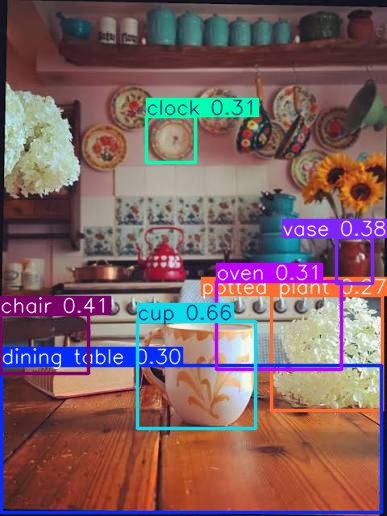


Summary: 1 relevant object(s) detected


In [ ]:
from google.colab import files

CONFIDENCE_THRESHOLD = 0.40   # minimum confidence to count as a detection

print("Upload a kitchen photo to test the CV model.\n")
print("Best results: real photo with cup, bottle, bowl, or plate visible.\n")

uploaded = files.upload()

for filename, data in uploaded.items():
    img_path = f"/content/{filename}"
    with open(img_path, "wb") as f:
        f.write(data)

    print(f"\nRunning detection on: {filename}\n")

    results = model(img_path, verbose=False)

    detected = []
    for result in results:
        for box in result.boxes:
            cid  = int(box.cls)
            conf = float(box.conf)

            if cid not in RELEVANT_IDS or conf < CONFIDENCE_THRESHOLD:
                continue

            name  = ALL_RELEVANT[cid]
            etype = "drink" if cid in DRINK_CLASSES else "food"
            detected.append((name, etype, conf))

            icon = "🥤" if etype == "drink" else "🍽️"
            print(f"  {icon}  {name:<16}  "
                  f"type: {etype:<7}  "
                  f"confidence: {conf:.2f}")

    if not detected:
        print("  No relevant objects detected.")
        print("  Try a clearer photo or lower CONFIDENCE_THRESHOLD above.")

    # Save and display annotated image with bounding boxes
    out_path = f"/content/cv_test_result.jpg"
    results[0].save(out_path)
    print(f"\nAnnotated image (bounding boxes drawn):")
    display(IPImage(out_path, width=600))

    print(f"\nSummary: {len(detected)} relevant object(s) detected")



---

## Stage 2A — Event Logging

Every detection the CV model produces needs to be written to persistent storage so the anomaly checker can read it later. This stage defines the database schema and logging functions that form the interface between detection and analysis.

---

### Create the database

Creates a SQLite database at `My Drive/ARGO_CAT/logs/argo_cat.db` with three tables:

| Table | Purpose |
|---|---|
| `events` | Every individual detection — one row per object detected. The raw data. |
| `daily_summary` | One row per day, pre-computed from the events table. This is what the anomaly checker reads from directly. |
| `prompt_log` | Tracks companion cat prompt outcomes. Used in Phase 2 when the cat interface is connected. |

The `is_synthetic` column distinguishes real camera detections (`0`) from synthetic simulation data (`1`), keeping the two cleanly separated throughout all downstream analysis.

In [ ]:
def create_database(db_path):
    conn = sqlite3.connect(db_path)
    c    = conn.cursor()

    c.execute("""
        CREATE TABLE IF NOT EXISTS events (
            id           INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp    TEXT    NOT NULL,
            object_name  TEXT    NOT NULL,
            confidence   REAL    NOT NULL,
            event_type   TEXT    NOT NULL,
            day_of_week  INTEGER NOT NULL,
            hour_of_day  INTEGER NOT NULL,
            week_number  INTEGER NOT NULL,
            is_synthetic INTEGER DEFAULT 0
        )
    """)

    c.execute("""
        CREATE TABLE IF NOT EXISTS daily_summary (
            id                        INTEGER PRIMARY KEY AUTOINCREMENT,
            date                      TEXT    NOT NULL UNIQUE,
            day_of_week               INTEGER NOT NULL,
            week_number               INTEGER NOT NULL,
            drink_count               INTEGER DEFAULT 0,
            meal_count                INTEGER DEFAULT 0,
            first_drink_hour          REAL,
            last_drink_hour           REAL,
            longest_drink_gap_minutes REAL    DEFAULT 0,
            is_synthetic              INTEGER DEFAULT 0
        )
    """)

    c.execute("""
        CREATE TABLE IF NOT EXISTS prompt_log (
            id                  INTEGER PRIMARY KEY AUTOINCREMENT,
            prompt_timestamp    TEXT    NOT NULL,
            prompt_type         TEXT    NOT NULL,
            response_detected   INTEGER DEFAULT 0,
            response_timestamp  TEXT,
            response_delay_mins REAL
        )
    """)

    conn.commit()
    return conn

conn = create_database(DB_PATH)
print("✅  Database created")
print(f"    Path   : {DB_PATH}")
print(f"    Tables : events, daily_summary, prompt_log")


✅  Database created
    Path   : /content/drive/MyDrive/ARGO_CAT/logs/argo_cat.db
    Tables : events, daily_summary, prompt_log


### Cooldown tracker

Prevents duplicate logging of static objects.

Without cooldown, a cup sitting still on a table would generate hundreds of identical log entries per minute — one per video frame. The cooldown allows one log entry per object per time window.

| Mode | Window | Use case |
|---|---|---|
| Testing | 5 seconds | Fast feedback while developing |
| Production | 30 seconds | Raspberry Pi deployment |

> We would Change `COOLDOWN_SECONDS = 5` to `COOLDOWN_SECONDS = 30` before deploying to Hardware.

In [ ]:
COOLDOWN_SECONDS = 5   # Must chnage to 30 for Phase 2 Hardware deployment

class CooldownTracker:
    """
    Prevents duplicate logging of static objects.
    Allows one database write per object per time window.
    """
    def __init__(self, seconds):
        self.window = seconds
        self.last   = {}

    def should_log(self, name):
        now = datetime.now()
        if name not in self.last:
            self.last[name] = now
            return True
        if (now - self.last[name]).total_seconds() >= self.window:
            self.last[name] = now
            return True
        return False

    def reset(self):
        """Call before processing a new image to clear cooldown state."""
        self.last = {}

cooldown = CooldownTracker(COOLDOWN_SECONDS)
print(f"✅  Cooldown tracker ready")
print(f"    Window : {COOLDOWN_SECONDS} seconds")
print(f"    Note   : change COOLDOWN_SECONDS to 30 for production")


✅  Cooldown tracker ready
    Window : 5 seconds
    Note   : change COOLDOWN_SECONDS to 30 for production


### Logging functions

Defines three functions that form the core of the logging pipeline:

**`log_to_db`** — writes one detection event to the SQLite database. Used by the anomaly checker.

**`log_to_csv`** — writes one detection event to the CSV log. Human readable, openable in Excel, shareable with the team.

**`detect_and_log`** — the main pipeline function. Runs YOLO on any image, filters for relevant classes, applies cooldown, and calls both logging functions for valid detections. This is the function all later cells call.

> Both storage formats are maintained in parallel — the database for structured queries, the CSV for human readability.

In [ ]:
def log_to_db(conn, name, conf, etype, is_synthetic=0):
    """Writes one detection event to the SQLite database."""
    now = datetime.now()
    conn.execute("""
        INSERT INTO events
        (timestamp, object_name, confidence, event_type,
         day_of_week, hour_of_day, week_number, is_synthetic)
        VALUES (?,?,?,?,?,?,?,?)
    """, (
        now.strftime("%Y-%m-%d %H:%M:%S"),
        name, round(conf, 3), etype,
        now.weekday(), now.hour,
        int(now.strftime("%W")),
        is_synthetic
    ))
    conn.commit()


def log_to_csv(name, conf, etype):
    """Writes one detection event to the CSV log."""
    file_exists = os.path.isfile(CSV_PATH)
    with open(CSV_PATH, "a", newline="") as f:
        writer = csv.DictWriter(
            f, fieldnames=["timestamp", "object_name",
                           "confidence", "event_type"])
        if not file_exists:
            writer.writeheader()
        writer.writerow({
            "timestamp":   datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "object_name": name,
            "confidence":  round(conf, 3),
            "event_type":  etype,
        })


def detect_and_log(image_path, threshold=0.40, verbose=True):
    """
    Runs YOLO on an image file.
    Filters for ARGO-CAT relevant classes above threshold.
    Applies cooldown to prevent duplicate logging.
    Writes valid detections to both database and CSV.
    Returns list of (object_name, event_type, confidence).
    """
    results = model(image_path, verbose=False)
    logged  = []

    for result in results:
        for box in result.boxes:
            cid  = int(box.cls)
            conf = float(box.conf)

            if cid not in RELEVANT_IDS or conf < threshold:
                continue

            name  = ALL_RELEVANT[cid]
            etype = "drink" if cid in DRINK_CLASSES else "food"

            if not cooldown.should_log(name):
                if verbose:
                    print(f"  ⏭️   {name:<16} skipped (cooldown active)")
                continue

            log_to_db(conn, name, conf, etype, is_synthetic=0)
            log_to_csv(name, conf, etype)
            logged.append((name, etype, conf))

            icon = "🥤" if etype == "drink" else "🍽️"
            if verbose:
                print(f"  {icon}  {name:<16} "
                      f"{etype:<7} conf:{conf:.2f}  ✅ logged")

    if not logged and verbose:
        print("  Nothing detected above threshold.")

    return logged


print("✅  Logging functions ready")
print("    log_to_db      : writes to SQLite")
print("    log_to_csv     : writes to CSV")
print("    detect_and_log : runs detection and calls both")

✅  Logging functions ready
    log_to_db      : writes to SQLite
    log_to_csv     : writes to CSV
    detect_and_log : runs detection and calls both


### Log a real detection from an uploaded image

Runs the fully integrated pipeline for the first time — detection and logging working together.

Upload a kitchen photo and the system will:
1. Run YOLO object detection
2. Filter for ARGO-CAT relevant classes
3. Apply cooldown
4. Write valid detections to both the SQLite database and the CSV log
5. Display the annotated image with bounding boxes

**Expected output:** Detection list with confidence scores, annotated image, and count of detections logged.

Upload a kitchen photo to run the full detection + logging pipeline.



Saving Image_2.jpg to Image_2.jpg

Running detection and logging on: Image_2.jpg

  🥤  cup              drink   conf:0.87  ✅ logged
  🍽️  dining table     food    conf:0.84  ✅ logged
  ⏭️   cup              skipped (cooldown active)
  ⏭️   cup              skipped (cooldown active)
  ⏭️   cup              skipped (cooldown active)
  🍽️  bowl             food    conf:0.68  ✅ logged
  ⏭️   cup              skipped (cooldown active)
  ⏭️   cup              skipped (cooldown active)


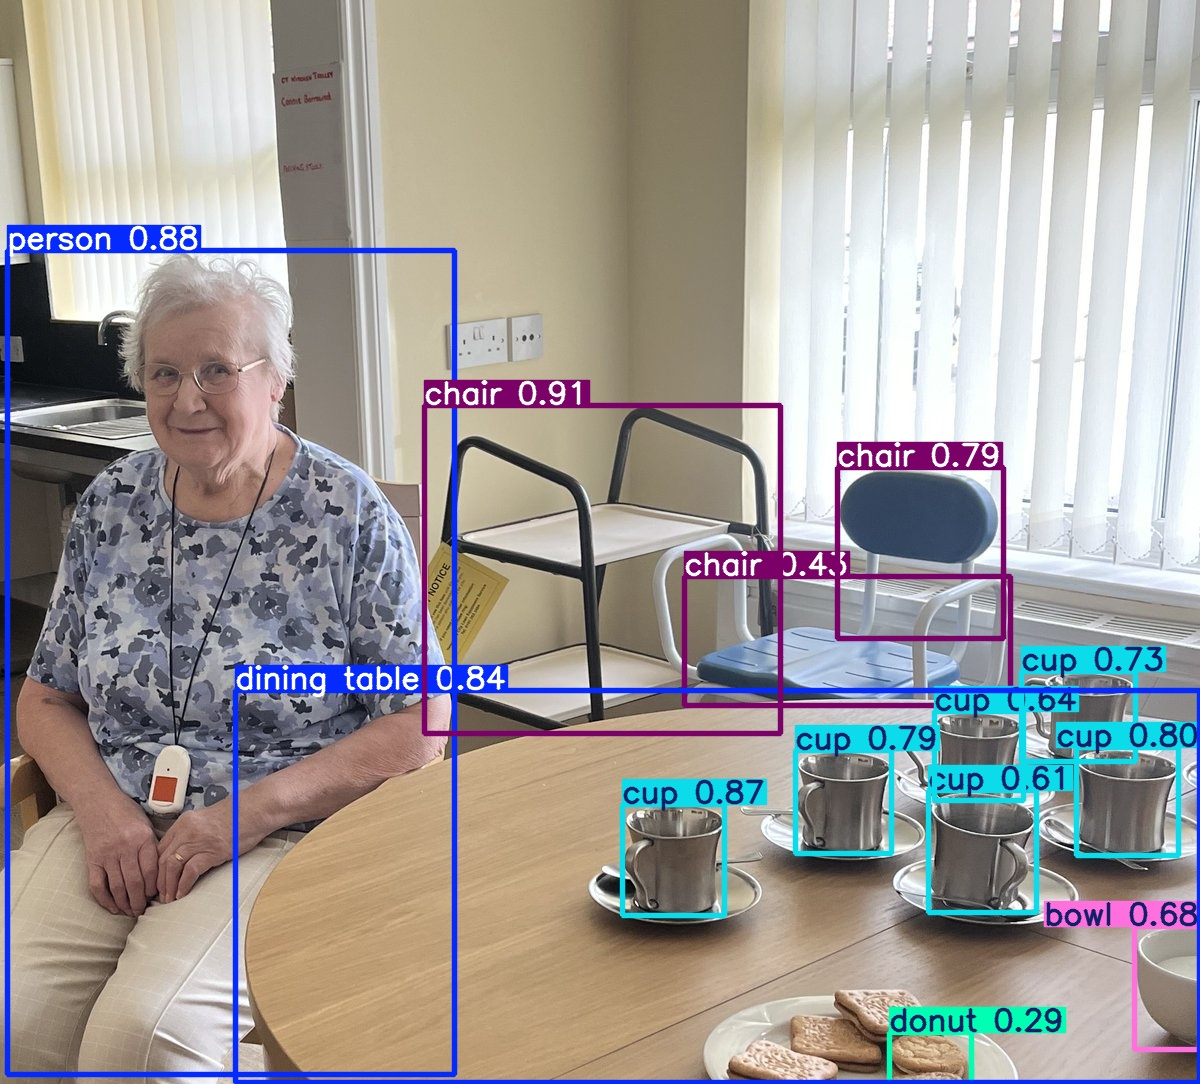


  3 detection(s) logged to database and CSV


In [ ]:
print("Upload a kitchen photo to run the full detection + logging pipeline.\n")

uploaded = files.upload()

for filename, data in uploaded.items():
    img_path = f"/content/{filename}"
    with open(img_path, "wb") as f:
        f.write(data)

    print(f"\nRunning detection and logging on: {filename}\n")
    cooldown.reset()
    logged = detect_and_log(img_path, verbose=True)

    # Show annotated result
    out_path = f"/content/logged_result_{filename}"
    model(img_path, verbose=False)[0].save(out_path)
    display(IPImage(out_path, width=600))

    print(f"\n  {len(logged)} detection(s) logged to database and CSV")

### View the detection log

Displays all real detections logged so far from both the database and CSV.

Shows a full event table, breakdown by event type (drink vs food), and breakdown by object with average confidence scores.

> Run this anytime during a session to verify detections are being logged correctly.

In [ ]:
print("=" * 50)
print("  DETECTION LOG — REAL DETECTIONS")
print("=" * 50)

# Database view
df_db = pd.read_sql_query("""
    SELECT timestamp, object_name, confidence, event_type
    FROM events
    WHERE is_synthetic = 0
    ORDER BY timestamp DESC
""", conn)

if df_db.empty:
    print("\n  No real detections yet. Run Cell 10 first.")
else:
    print(f"\n  Total real detections : {len(df_db)}")
    print(f"\n  Full log (database):\n")
    print(df_db.to_string(index=False))

    print(f"\n  By event type:")
    print(df_db.groupby("event_type")["object_name"]
              .count().to_string())

    print(f"\n  By object:")
    print(df_db.groupby("object_name")["confidence"]
              .agg(["count", "mean"])
              .rename(columns={"count": "n", "mean": "avg_conf"})
              .round(2).to_string())

# CSV view
print(f"\n  CSV log at: {CSV_PATH}")
if os.path.isfile(CSV_PATH):
    df_csv = pd.read_csv(CSV_PATH)
    print(f"  CSV rows  : {len(df_csv)}")
else:
    print("  CSV not yet created.")



  DETECTION LOG — REAL DETECTIONS

  Total real detections : 24

  Full log (database):

          timestamp  object_name  confidence event_type
2026-07-21 18:48:13 dining table       0.839       food
2026-07-21 18:48:13         bowl       0.678       food
2026-07-21 18:48:12          cup       0.872      drink
2026-07-21 17:39:03         bowl       0.709       food
2026-07-21 17:39:03          cup       0.669      drink
2026-07-21 17:39:03         fork       0.403       food
2026-07-21 17:39:02 dining table       0.815       food
2026-07-21 17:38:24          cup       0.867      drink
2026-07-21 17:38:24 dining table       0.838       food
2026-07-21 17:38:24         bowl       0.606       food
2026-07-21 17:38:03          cup       0.811      drink
2026-07-21 17:38:03 dining table       0.540       food
2026-07-21 17:31:55 dining table       0.815       food
2026-07-21 17:31:55         bowl       0.709       food
2026-07-21 17:31:55          cup       0.669      drink
2026-07-21 17:3

---

## Stage 2B — Synthetic Data Generation

Now that the CV pipeline and logging infrastructure are established, synthetic data populates the same database using the same schema and same event types.

The database structure is defined by the real pipeline. Synthetic data simulates what that pipeline would produce over 30 days of continuous deployment — making the dependency explicit and the architecture logical.

The anomaly checker requires at least 14 days of behavioral history to build a reliable personal baseline. Synthetic data provides that immediately, making the system testable from day one. As real data accumulates the synthetic baseline is gradually replaced.

---

### Define the behavioral profile

Defines the simulated person's normal eating and drinking routine.

Values are grounded in NHATS-based published literature on community-dwelling older adults with MCI:
- Six typical drinking occasions per day
- Three meals per day
- Natural day-to-day variation modeled with Gaussian noise

**Anomaly design:**

| Period | Days | Behavior |
|---|---|---|
| Normal | 1 – 21 | Stable routine, 5–6 drinks per day |
| Anomaly | 22 – 30 | Hydration declines progressively — skip probability increases each day |

This simulates the slow, gradual behavioral shift that ARGO-CAT is designed to detect before it becomes a clinical event.

In [ ]:
BEHAVIORAL_PROFILE = {
    "drink_times":     [7.5, 9.5, 12.0, 14.5, 17.0, 19.5],
    "drink_std":       0.4,
    "meal_times":      [8.0, 13.0, 18.5],
    "meal_std":        0.3,
    "skip_drink_prob": 0.08,   # 8%  chance of skipping a drink occasion
    "skip_meal_prob":  0.10,   # 10% chance of skipping a meal
}

# Object names matching the COCO classes defined in Cell 5
SYNTHETIC_DRINK_OBJECTS = ["cup", "bottle", "glass"]
SYNTHETIC_FOOD_OBJECTS  = ["bowl", "fork", "spoon"]

SIM_DAYS     = 30
ANOMALY_DAY  = 22
SIM_START    = datetime.now() - timedelta(days=SIM_DAYS)

print("✅  Behavioral profile defined")
print(f"    Simulation period : {SIM_DAYS} days")
print(f"    Normal days       : 1 to {ANOMALY_DAY - 1}")
print(f"    Anomaly days      : {ANOMALY_DAY} to {SIM_DAYS}")
print(f"    Drink times       : {BEHAVIORAL_PROFILE['drink_times']}")
print(f"    Meal times        : {BEHAVIORAL_PROFILE['meal_times']}")


✅  Behavioral profile defined
    Simulation period : 30 days
    Normal days       : 1 to 21
    Anomaly days      : 22 to 30
    Drink times       : [7.5, 9.5, 12.0, 14.5, 17.0, 19.5]
    Meal times        : [8.0, 13.0, 18.5]


### Generate synthetic behavioral history

Populates the database with 30 days of simulated events and daily summaries.

**Expected output:**
- A 30-row table showing drink count per day
- Rows 1–21 show 4–6 drinks per day marked `✅ NORMAL`
- Rows 22–30 show a visible decline marked `🔴 ANOMALY`
- Summary statistics at the bottom confirming the reduction percentage

> Do not re-run this cell unnecessarily. It clears and regenerates synthetic data each time it runs. Real detections are not affected.

In [ ]:
def generate_synthetic_data(conn):
    c = conn.cursor()

    # Clear any previously generated synthetic data
    c.execute("DELETE FROM events WHERE is_synthetic = 1")
    c.execute("DELETE FROM daily_summary WHERE is_synthetic = 1")
    conn.commit()

    total_events = 0

    print(f"  {'Day':<5} {'Date':<13} {'Drinks':<9} "
          f"{'Meals':<8} {'Longest gap (min)':<20} {'Status'}")
    print("  " + "─" * 66)

    for day in range(SIM_DAYS):
        date     = SIM_START + timedelta(days=day)
        date_str = date.strftime("%Y-%m-%d")
        dow      = date.weekday()
        week     = int(date.strftime("%W"))

        drink_count = 0
        meal_count  = 0
        drink_hours = []
        rows        = []

        # ── Generate drink events ────────────────────────
        for base_hr in BEHAVIORAL_PROFILE["drink_times"]:

            # Progressive skip probability during anomaly period
            if day >= ANOMALY_DAY:
                days_in   = day - ANOMALY_DAY
                skip_prob = min(
                    BEHAVIORAL_PROFILE["skip_drink_prob"] + days_in * 0.07,
                    0.90
                )
            else:
                skip_prob = BEHAVIORAL_PROFILE["skip_drink_prob"]

            if random.random() < skip_prob:
                continue

            hr   = max(6.0, min(23.0,
                   base_hr + random.gauss(
                       0, BEHAVIORAL_PROFILE["drink_std"])))
            obj  = random.choice(SYNTHETIC_DRINK_OBJECTS)
            conf = round(random.uniform(0.72, 0.97), 2)
            ts   = date.replace(
                hour   = int(hr),
                minute = int((hr % 1) * 60),
                second = random.randint(0, 59)
            )

            rows.append((
                ts.strftime("%Y-%m-%d %H:%M:%S"),
                obj, conf, "drink", dow, int(hr), week, 1
            ))
            drink_count += 1
            drink_hours.append(hr)

        # ── Generate meal events ─────────────────────────
        for base_hr in BEHAVIORAL_PROFILE["meal_times"]:

            skip_prob = (
                BEHAVIORAL_PROFILE["skip_meal_prob"] + 0.20
                if day >= ANOMALY_DAY + 4
                else BEHAVIORAL_PROFILE["skip_meal_prob"]
            )

            if random.random() < skip_prob:
                continue

            hr = max(6.0, min(22.0,
                 base_hr + random.gauss(
                     0, BEHAVIORAL_PROFILE["meal_std"])))
            meal_count += 1

            for obj in [random.choice(SYNTHETIC_FOOD_OBJECTS)
                        for _ in range(random.randint(2, 3))]:
                conf = round(random.uniform(0.75, 0.96), 2)
                ts   = date.replace(
                    hour   = int(hr),
                    minute = int((hr % 1) * 60),
                    second = random.randint(0, 59)
                )
                rows.append((
                    ts.strftime("%Y-%m-%d %H:%M:%S"),
                    obj, conf, "food", dow, int(hr), week, 1
                ))

        # ── Write to database ────────────────────────────
        c.executemany("""
            INSERT INTO events
            (timestamp, object_name, confidence, event_type,
             day_of_week, hour_of_day, week_number, is_synthetic)
            VALUES (?,?,?,?,?,?,?,?)
        """, rows)
        total_events += len(rows)

        # ── Compute daily summary ────────────────────────
        if drink_hours:
            sh   = sorted(drink_hours)
            gaps = [(sh[i+1]-sh[i])*60 for i in range(len(sh)-1)]
            lgap = round(max(gaps), 1) if gaps else 0.0
            f_hr = sh[0]
            l_hr = sh[-1]
        else:
            lgap = 24 * 60.0
            f_hr = None
            l_hr = None

        c.execute("""
            INSERT OR REPLACE INTO daily_summary
            (date, day_of_week, week_number,
             drink_count, meal_count,
             first_drink_hour, last_drink_hour,
             longest_drink_gap_minutes, is_synthetic)
            VALUES (?,?,?,?,?,?,?,?,?)
        """, (date_str, dow, week,
              drink_count, meal_count,
              f_hr, l_hr, lgap, 1))

        status = "🔴 ANOMALY" if day >= ANOMALY_DAY else "✅ NORMAL"
        print(f"  {day+1:<5} {date_str:<13} {drink_count:<9} "
              f"{meal_count:<8} {lgap:<20.0f} {status}")

    conn.commit()

    # ── Summary statistics ───────────────────────────────
    df = pd.read_sql_query("""
        SELECT drink_count FROM daily_summary
        WHERE is_synthetic = 1
        ORDER BY date
    """, conn)

    n_avg = df.head(ANOMALY_DAY)["drink_count"].mean()
    a_avg = df.tail(SIM_DAYS - ANOMALY_DAY)["drink_count"].mean()
    drop  = ((n_avg - a_avg) / n_avg) * 100

    print("\n" + "─" * 66)
    print(f"  Total events written          : {total_events}")
    print(f"  Normal period  avg drinks/day : {n_avg:.1f}")
    print(f"  Anomaly period avg drinks/day : {a_avg:.1f}")
    print(f"  Reduction                     : {drop:.0f}%")
    print(f"\n  ✅  Synthetic history written to database")


generate_synthetic_data(conn)

  Day   Date          Drinks    Meals    Longest gap (min)    Status
  ──────────────────────────────────────────────────────────────────
  1     2026-06-21    5         3        194                  ✅ NORMAL
  2     2026-06-22    6         3        171                  ✅ NORMAL
  3     2026-06-23    6         2        231                  ✅ NORMAL
  4     2026-06-24    6         2        208                  ✅ NORMAL
  5     2026-06-25    6         3        186                  ✅ NORMAL
  6     2026-06-26    4         2        400                  ✅ NORMAL
  7     2026-06-27    6         3        210                  ✅ NORMAL
  8     2026-06-28    5         2        178                  ✅ NORMAL
  9     2026-06-29    6         3        167                  ✅ NORMAL
  10    2026-06-30    6         3        245                  ✅ NORMAL
  11    2026-07-01    6         3        189                  ✅ NORMAL
  12    2026-07-02    6         3        218                  ✅ NORMAL
  13    20

---

## Stage 3 — Anomaly Detection

With the CV pipeline producing real detections and the database populated with synthetic behavioral history, the anomaly checker can now compute personalized risk scores.

This stage implements **Probabilistic Risk Score**

---

### Compute today's daily summary

Reads today's real detections and writes one daily summary row to the `daily_summary` table.

The daily summary captures:
- Total drink events today
- Total meal events today
- First and last drink hour
- Longest gap between drinks in minutes

This pre-computation keeps the anomaly checker lightweight — it reads one row per day rather than scanning all raw events every time it runs.

> Run this after logging real detections in Cell 10. If no real detections exist the cell will prompt you to log some first.

In [ ]:
def compute_daily_summary(conn, date_str=None):
    """
    Reads real events for a given date and writes one
    daily summary row to the daily_summary table.
    """
    if date_str is None:
        date_str = datetime.now().strftime("%Y-%m-%d")

    df = pd.read_sql_query(f"""
        SELECT * FROM events
        WHERE date(timestamp) = '{date_str}'
        AND is_synthetic = 0
    """, conn)

    if df.empty:
        print(f"  No real detections found for {date_str}.")
        print("  Run Cell 10 to log real detections first.")
        return None

    drinks  = df[df["event_type"] == "drink"]
    meals   = df[df["event_type"] == "food"]
    d_hrs   = sorted(drinks["hour_of_day"].tolist())

    if len(d_hrs) > 1:
        gaps = [(d_hrs[i+1] - d_hrs[i]) * 60
                for i in range(len(d_hrs) - 1)]
        lgap = round(max(gaps), 1)
    elif len(d_hrs) == 1:
        lgap = round((datetime.now().hour - d_hrs[0]) * 60, 1)
    else:
        lgap = 24 * 60.0

    now = datetime.now()
    conn.execute("""
        INSERT OR REPLACE INTO daily_summary
        (date, day_of_week, week_number,
         drink_count, meal_count,
         first_drink_hour, last_drink_hour,
         longest_drink_gap_minutes, is_synthetic)
        VALUES (?,?,?,?,?,?,?,?,0)
    """, (
        date_str,
        now.weekday(),
        int(now.strftime("%W")),
        len(drinks), len(meals),
        d_hrs[0]  if d_hrs else None,
        d_hrs[-1] if d_hrs else None,
        lgap
    ))
    conn.commit()

    print(f"  Daily summary — {date_str}")
    print(f"    Drink count   : {len(drinks)}")
    print(f"    Meal count    : {len(meals)}")
    if d_hrs:
        print(f"    First drink   : {d_hrs[0]:.1f}h")
        print(f"    Last drink    : {d_hrs[-1]:.1f}h")
    else:
        print(f"    First drink   : none detected")
    print(f"    Longest gap   : {lgap:.0f} min")
    print(f"\n  ✅  Summary saved")

    return {"drinks": len(drinks), "meals": len(meals), "lgap": lgap}


print("Computing today's daily summary from real detections...\n")
compute_daily_summary(conn)


Computing today's daily summary from real detections...

  Daily summary — 2026-07-21
    Drink count   : 8
    Meal count    : 15
    First drink   : 17.0h
    Last drink    : 18.0h
    Longest gap   : 60 min

  ✅  Summary saved


{'drinks': 8, 'meals': 15, 'lgap': 60}

### Risk scorer

The core anomaly detection function. Implements Option 1 from the behavioral model options document.

**Baseline logic — two stages:**

| Stage | Condition | Source |
|---|---|---|
| Population prior | Fewer than 14 days of history | NHATS-based published literature on older adults with MCI |
| Personal baseline | 14 or more days of history | Computed from this individual's own accumulated event history |

The transition happens automatically. The synthetic data from Stage 3 already provides the 30-day history needed to activate the personal baseline immediately.

**Hydration risk calculation:**
1. Compute current gap since last drink in minutes
2. Calculate z-score: how many standard deviations above normal is this gap?
3. Map z-score to a 0–1 probability via sigmoid function
4. Classify action based on hours since last drink

**Nutrition risk calculation:**
Compare meal events logged today against expected meal count by the current hour of day.

**Longitudinal trend:**
Linear regression across weekly average drink counts to detect a declining trend over time.

**Output actions:**

| Icon | Action | Condition |
|---|---|---|
| 🟢 | NORMAL | Within expected range |
| 🟡 | PROMPT | Trigger companion cat intervention |
| 🔴 | ALERT | Notify caregiver |

In [ ]:
POPULATION_PRIOR = {
    "mean_gap_min":  180,    # avg older adult drinks every 3 hours
    "std_gap_min":    45,    # typical variation around that mean
    "mean_drinks":     6.0,  # avg drinks per day
    "std_drinks":      1.2,
    "mean_meals":      2.8,
}

PERSONAL_MIN_DAYS   = 14    # days before switching to personal baseline
PROMPT_THRESHOLD_HR = 2.5   # hours → trigger cat prompt
ALERT_THRESHOLD_HR  = 4.0   # hours → notify caregiver


def get_baseline(conn):
    """
    Returns population prior until enough personal data exists,
    then switches to personal baseline computed from history.
    """
    history = pd.read_sql_query("""
        SELECT drink_count, longest_drink_gap_minutes
        FROM daily_summary
        ORDER BY date DESC
        LIMIT 30
    """, conn)

    n = len(history)

    if n >= PERSONAL_MIN_DAYS:
        mean_gap = history["longest_drink_gap_minutes"].mean()
        std_gap  = max(history["longest_drink_gap_minutes"].std(), 1.0)
        source   = f"personal ({n} days of history)"
    else:
        mean_gap = POPULATION_PRIOR["mean_gap_min"]
        std_gap  = POPULATION_PRIOR["std_gap_min"]
        days_rem = PERSONAL_MIN_DAYS - n
        source   = (f"population prior / NHATS  "
                    f"({days_rem} more day(s) until personal baseline)")

    return {"mean_gap": mean_gap, "std_gap": std_gap, "source": source}


def compute_risk_score(conn):
    """
    Main anomaly checking function.
    Reads the event history and daily summary.
    Returns a dictionary of risk scores and recommended actions.
    """
    today = datetime.now().strftime("%Y-%m-%d")
    now   = datetime.now()
    bl    = get_baseline(conn)

    # ── Hydration ─────────────────────────────────────────
    last_drink = pd.read_sql_query(f"""
        SELECT timestamp FROM events
        WHERE event_type  = 'drink'
        AND   is_synthetic = 0
        AND   date(timestamp) = '{today}'
        ORDER BY timestamp DESC
        LIMIT 1
    """, conn)

    if last_drink.empty:
        hrs_since = now.hour + now.minute / 60
        last_str  = "no drink detected today"
    else:
        lt        = pd.to_datetime(last_drink["timestamp"].iloc[0])
        hrs_since = (now - lt).total_seconds() / 3600
        last_str  = last_drink["timestamp"].iloc[0]

    gap_min = hrs_since * 60
    z       = max(0.0, (gap_min - bl["mean_gap"]) / bl["std_gap"])
    h_risk  = round(1 / (1 + np.exp(-0.8 * (z - 2))), 2)

    if hrs_since >= ALERT_THRESHOLD_HR:
        h_action, h_icon = "ALERT  — notify caregiver",          "🔴"
    elif hrs_since >= PROMPT_THRESHOLD_HR:
        h_action, h_icon = "PROMPT — trigger cat intervention",   "🟡"
    else:
        h_action, h_icon = "NORMAL",                              "🟢"

    # ── Nutrition ──────────────────────────────────────────
    meal_n = pd.read_sql_query(f"""
        SELECT COUNT(DISTINCT strftime('%H', timestamp)) as n
        FROM   events
        WHERE  event_type   = 'food'
        AND    is_synthetic = 0
        AND    date(timestamp) = '{today}'
    """, conn).iloc[0]["n"]

    expected = (1 if now.hour < 11 else
                2 if now.hour < 15 else 3)
    behind   = max(0, expected - meal_n)
    m_risk   = round(min(1.0, behind / 3.0), 2)

    if behind >= 2:
        m_action, m_icon = "ALERT  — multiple meals missed",         "🔴"
    elif behind >= 1:
        m_action, m_icon = "PROMPT — meal activity below expected",   "🟡"
    else:
        m_action, m_icon = "NORMAL",                                  "🟢"

    # ── Longitudinal trend ─────────────────────────────────
    weekly = pd.read_sql_query("""
        SELECT week_number,
               AVG(drink_count) as avg_drinks
        FROM   daily_summary
        GROUP  BY week_number
        ORDER  BY week_number
    """, conn)

    if len(weekly) >= 2:
        from scipy import stats as sp
        slope, _, _, pval, _ = sp.linregress(
            range(len(weekly)),
            weekly["avg_drinks"].values
        )
        if slope < -0.3 and pval < 0.1:
            trend = f"DECLINING  ({slope:.1f} drinks/day/week)"
        else:
            trend = "STABLE"
    else:
        trend = "insufficient data (need 2 or more weeks)"

    # ── Print risk assessment ─────────────────────────────
    sep = "=" * 56
    print(sep)
    print("  ARGO-CAT  RISK ASSESSMENT")
    print(f"  {now.strftime('%Y-%m-%d   %H:%M:%S')}")
    print(sep)

    print(f"\n  Baseline : {bl['source']}")

    print(f"\n  HYDRATION  {h_icon}")
    print(f"    Last drink detected    : {last_str}")
    print(f"    Hours since last drink : {hrs_since:.1f} hrs")
    print(f"    Gap z-score            : {z:.2f}")
    print(f"    Risk score             : {h_risk:.2f}"
          "   (0 = normal   1 = high risk)")
    print(f"    Action                 : {h_action}")

    print(f"\n  NUTRITION  {m_icon}")
    print(f"    Meal events today      : {int(meal_n)}")
    print(f"    Expected by now        : {expected}")
    print(f"    Meals behind           : {behind}")
    print(f"    Risk score             : {m_risk:.2f}"
          "   (0 = normal   1 = high risk)")
    print(f"    Action                 : {m_action}")

    print(f"\n  LONGITUDINAL TREND")
    print(f"    Weekly drinking trend  : {trend}")

    print("\n" + sep)

    return {
        "hydration_risk":    h_risk,
        "nutrition_risk":    m_risk,
        "hydration_action":  h_action,
        "nutrition_action":  m_action,
        "hours_since_drink": round(hrs_since, 1),
        "meals_today":       int(meal_n),
        "trend":             trend,
    }


result = compute_risk_score(conn)


  ARGO-CAT  RISK ASSESSMENT
  2026-07-21   18:48:42

  Baseline : personal (30 days of history)

  HYDRATION  🟢
    Last drink detected    : 2026-07-21 18:48:12
    Hours since last drink : 0.0 hrs
    Gap z-score            : 0.00
    Risk score             : 0.17   (0 = normal   1 = high risk)
    Action                 : NORMAL

  NUTRITION  🟡
    Meal events today      : 2
    Expected by now        : 3
    Meals behind           : 1
    Risk score             : 0.33   (0 = normal   1 = high risk)
    Action                 : PROMPT — meal activity below expected

  LONGITUDINAL TREND
    Weekly drinking trend  : STABLE



### Full database summary

Provides a complete view of everything stored in the database — both synthetic and real data — for verification and team review.

Shows:
- Event counts broken down by source (real vs synthetic) and type (drink vs food)
- Last 10 rows of the daily summary table
- Total counts and file paths for both the database and CSV log

> This is to confirm the pipeline has been working correctly throughout.

In [ ]:
print("=" * 56)
print("  DATABASE SUMMARY")
print("=" * 56)

# Events table
ev = pd.read_sql_query("""
    SELECT
        is_synthetic,
        event_type,
        COUNT(*) as count
    FROM events
    GROUP BY is_synthetic, event_type
    ORDER BY is_synthetic, event_type
""", conn)
ev["source"] = ev["is_synthetic"].map({0: "real", 1: "synthetic"})
print("\n  Events table:")
print(ev[["source","event_type","count"]].to_string(index=False))

# Daily summary table
ds = pd.read_sql_query("""
    SELECT date, drink_count, meal_count,
           longest_drink_gap_minutes, is_synthetic
    FROM daily_summary
    ORDER BY date DESC
    LIMIT 10
""", conn)
ds["source"] = ds["is_synthetic"].map({0: "real", 1: "synthetic"})
print(f"\n  Daily summary (last 10 rows):")
print(ds[["date","drink_count","meal_count",
          "longest_drink_gap_minutes","source"]]
      .to_string(index=False))

# Totals
total_events  = conn.execute(
    "SELECT COUNT(*) FROM events").fetchone()[0]
total_days    = conn.execute(
    "SELECT COUNT(*) FROM daily_summary").fetchone()[0]
real_events   = conn.execute(
    "SELECT COUNT(*) FROM events WHERE is_synthetic=0").fetchone()[0]
synth_events  = conn.execute(
    "SELECT COUNT(*) FROM events WHERE is_synthetic=1").fetchone()[0]

print(f"\n  Total events in database  : {total_events}")
print(f"    Real detections         : {real_events}")
print(f"    Synthetic               : {synth_events}")
print(f"  Total days in summary     : {total_days}")
print(f"\n  Database path : {DB_PATH}")
print(f"  CSV log path  : {CSV_PATH}")

  DATABASE SUMMARY

  Events table:
   source event_type  count
     real      drink      9
     real       food     15
synthetic      drink    158
synthetic       food    211

  Daily summary (last 10 rows):
      date  drink_count  meal_count  longest_drink_gap_minutes    source
2026-07-21            8          15                       60.0      real
2026-07-20            1           2                        0.0 synthetic
2026-07-19            3           3                      590.6 synthetic
2026-07-18            3           2                      404.8 synthetic
2026-07-17            3           2                      108.8 synthetic
2026-07-16            3           3                      185.5 synthetic
2026-07-15            6           3                      165.7 synthetic
2026-07-14            6           3                      196.9 synthetic
2026-07-13            6           3                      195.8 synthetic
2026-07-12            6           3                      187.